### Section 3 & 4: Classification Methods and Results

##### Preprocessing before methods application

In [1]:
## Preprocessing
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
file_path = "/Users/sunsally/Desktop/Red-wine-quality-classification/data/winequality-red.csv"

df = pd.read_csv(file_path, sep=";", quotechar='"')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Binary class distribution:
0    744
1    855
Name: quality_binary, dtype: int64


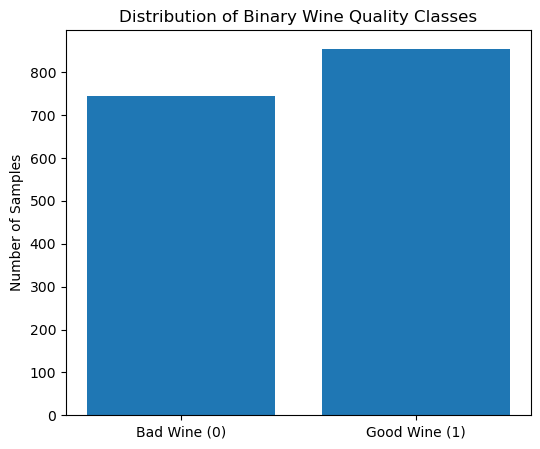

In [ ]:
# Convert quality into binary classification target
# quality >= 6: good wine = 1
# quality < 6: bad wine = 0

df['quality_binary'] = (df['quality'] >= 6).astype(int)

binary_counts = df['quality_binary'].value_counts().sort_index()

print("Binary class distribution:")
print(binary_counts)

plt.figure(figsize=(6, 5))
plt.bar(["Bad Wine (0)", "Good Wine (1)"], binary_counts.values)
plt.ylabel("Number of Samples")
plt.title("Distribution of Binary Wine Quality Classes")
plt.show()

In [7]:
# Define features X and target y

X = df.drop(columns=['quality', 'quality_binary'])
y = df['quality_binary']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

display(X.head())

Feature matrix shape: (1599, 11)
Target vector shape: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [8]:
# Train-test split
# stratify=y keeps the good/bad ratio similar in train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train distribution:
1    0.534793
0    0.465207
Name: quality_binary, dtype: float64

y_test distribution:
1    0.534375
0    0.465625
Name: quality_binary, dtype: float64


In [9]:
# Feature scaling (Preparation for SVM)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for easier reading
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
745,-0.590966,-0.088985,-0.479265,-0.318464,-0.362708,-0.376379,-0.555343,0.485602,1.350662,0.432631,-0.874168
823,-0.932515,0.078962,-0.737340,-0.390869,-0.232593,-0.082760,-0.314237,0.288102,1.935417,-0.111633,-0.594279
983,0.433678,-0.144968,0.140115,-0.463274,-0.471137,-0.767871,-0.886864,0.516786,0.051206,0.311684,0.058793
1505,-0.932515,1.310575,-1.305106,-0.535679,-0.189221,-0.963618,-1.037555,-0.387555,1.545580,-0.172107,-0.454335
1399,-0.647891,0.806733,-1.408336,-0.246059,-0.406080,-0.572125,-0.675896,-0.595449,0.700934,0.372157,0.618570


In [10]:
# Final preprocessing check

print("Preprocessing complete.")
print("Unscaled training data:", X_train.shape)
print("Scaled training data:", X_train_scaled.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Preprocessing complete.
Unscaled training data: (1279, 11)
Scaled training data: (1279, 11)
Training target: (1279,)
Testing target: (320,)


##### Method 1: Logicstic Regression (baseline)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train_scaled, y_train)

# Predict
y_pred_log = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:")
print(log_accuracy)

Logistic Regression Accuracy:
0.740625


In [12]:
# Confusion Matrix

cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix:")
print(cm_log)

Confusion Matrix:
[[111  38]
 [ 45 126]]


In [13]:
print("Classification Report:")

print(classification_report(
    y_test,
    y_pred_log
))

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       149
           1       0.77      0.74      0.75       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted avg       0.74      0.74      0.74       320



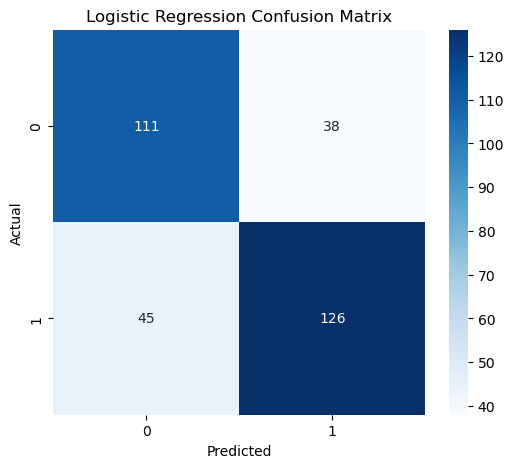

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Method 2: Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.81875


In [16]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[123  26]
 [ 32 139]]


In [17]:
print("Random Forest Classification Report:")

print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       149
           1       0.84      0.81      0.83       171

    accuracy                           0.82       320
   macro avg       0.82      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320



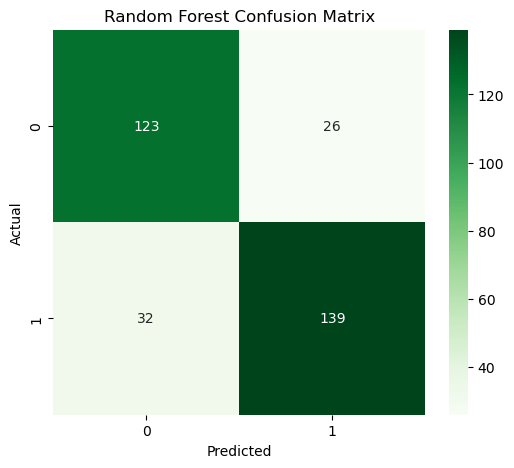

In [18]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Method 3: Support Vector Machine(SVM)

In [19]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:")
print(svm_accuracy)

SVM Accuracy:
0.7625


In [20]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

SVM Confusion Matrix:
[[121  28]
 [ 48 123]]


In [21]:
print("SVM Classification Report:")

print(classification_report(
    y_test,
    y_pred_svm
))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       149
           1       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



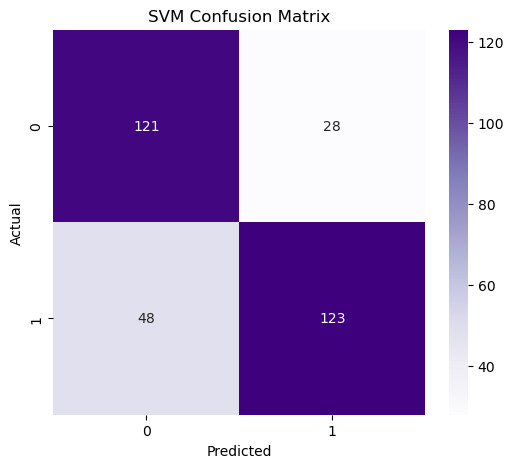

In [22]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Comparison between methods

In [23]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [log_accuracy, rf_accuracy, svm_accuracy]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.740625
1        Random Forest  0.818750
2                  SVM  0.762500


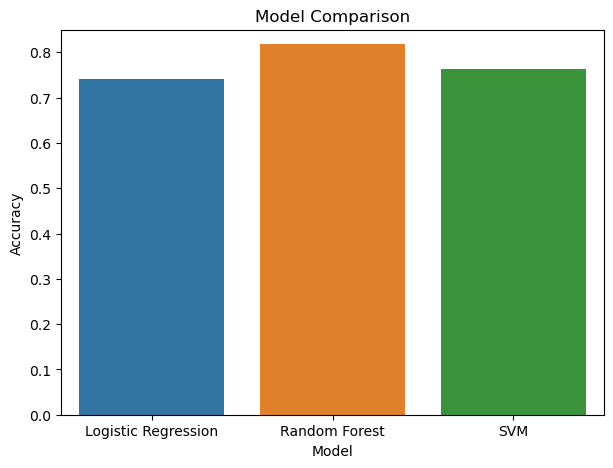

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("Model Comparison")
plt.ylim(0, 0.85)
plt.show()

##### Feature importance for Random Forest (Method 2)

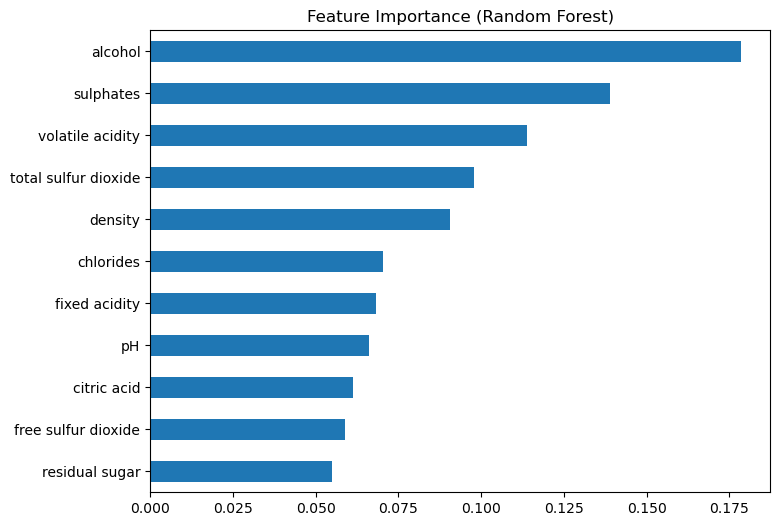

In [26]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance (Random Forest)")
plt.show()

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

Best params: {'max_depth': None, 'n_estimators': 200}
